CCS Analysis

Comparison of carbon capture and storage (CCS) pathways for California under scenario 1 (coordinated) and scenario 2 (uncoordianted)


Setup (REMEMBER TO RESTART BEFORE EACH RUN!)

In [1]:
import networkx as nx
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import hashlib
import scenario_analysis_graphs as sag
import scenario_analysis_w1_1 as sa11
import scenario_analysis_w1_2 as sa12
import scenario_analysis_w2 as sa2

In [7]:
import importlib
importlib.reload(sa11)
importlib.reload(sa12)
importlib.reload(sa2)
importlib.reload(sag)

<module 'scenario_analysis_graphs' from '/Users/michaelgan/Desktop/CCS Research/Modeling/scenario_analysis_graphs.py'>

Base Parameters

In [3]:
BASELINE11 = dict(
    base_rate=0.05, max_rate=0.2, frac_split=(0.2, 0.8),
    cap_tolerance=48,
    sampling = True
)

BASELINE12 = dict(
    base_rate=0.05, max_rate=0.2, frac_split=(0.4, 0.6), hammock_threshold=0.5,
    cap_tolerance=48,
    sampling = True
)

BASELINE2 = dict(
    base_rate=0.1, max_rate=0.3, late_penalty=0.3, threshold_frac=0.7,
    capture_tolerance=48, transport_tolerance=48, storage_tolerance=48,
    sampling = True
)

Deployment Schedules

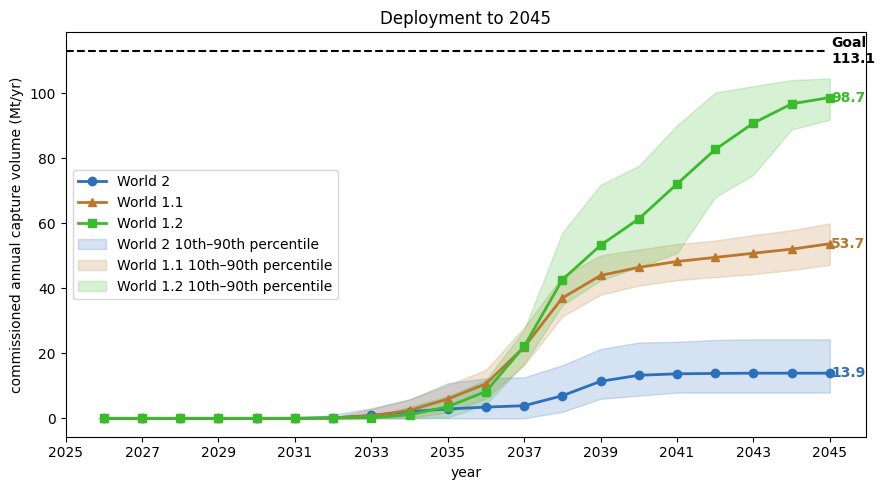

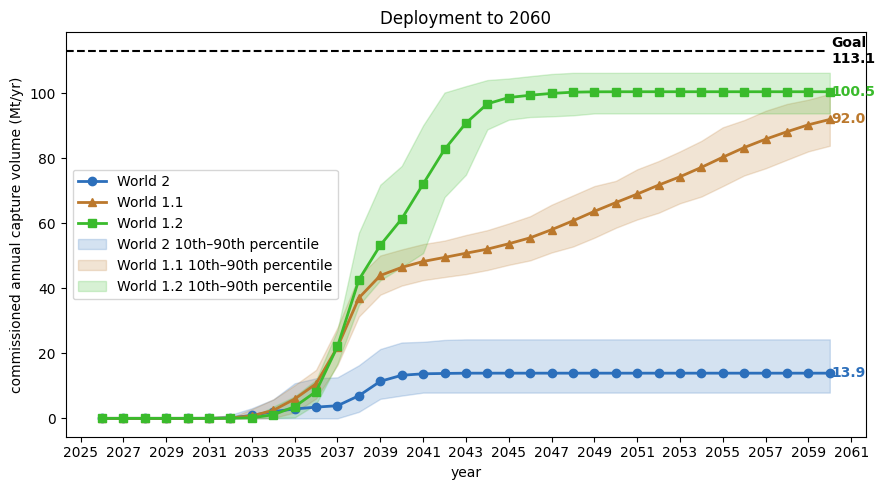

In [4]:
w11_results, w11_nodes = sa11.monte_carlo(300,
    **BASELINE11
)

w12_results, w12_nodes = sa12.monte_carlo(300,
    **BASELINE12
)

w2_results, w2_nodes = sa2.monte_carlo(300,
    **BASELINE2
)

sag.deployment_over_time_compare(w11_nodes, w12_nodes, w2_nodes, 2045)
sag.deployment_over_time_compare(w11_nodes, w12_nodes, w2_nodes, 2060)

Final Volume Distributions 

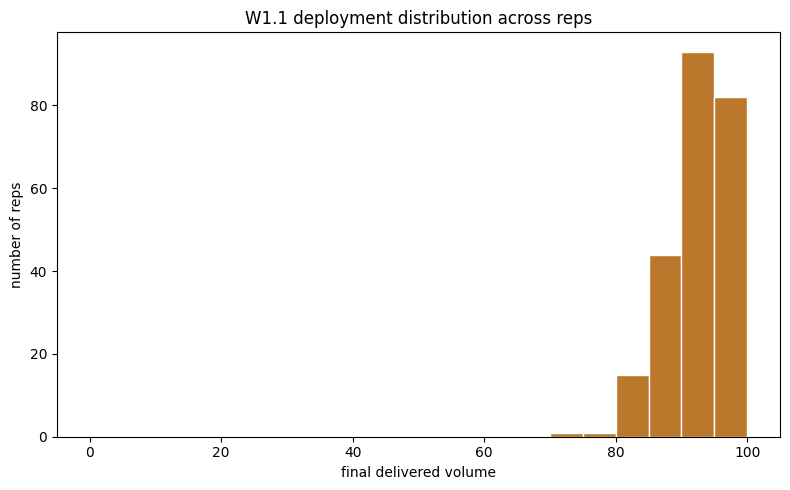

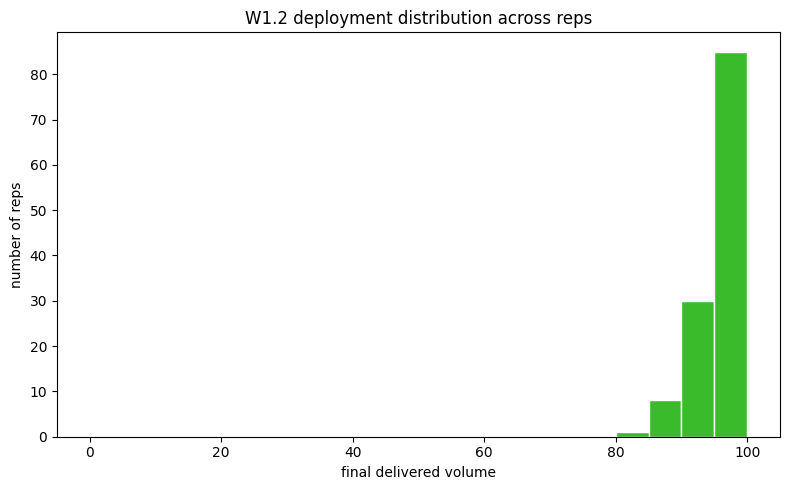

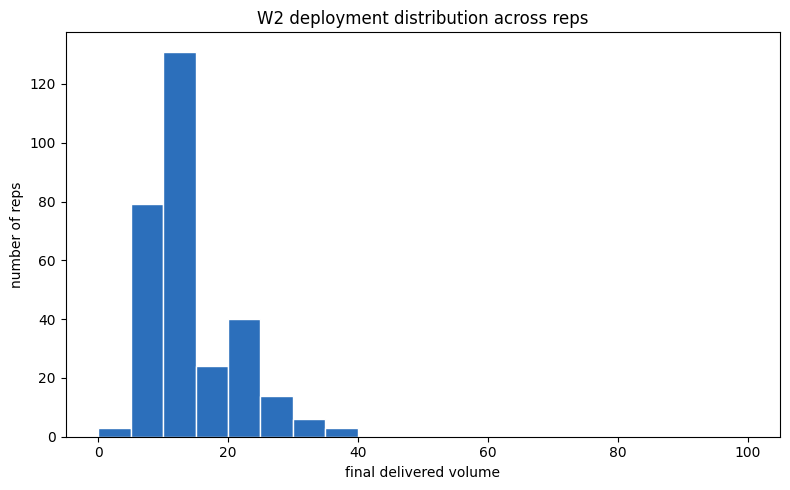

In [8]:
sag.w11_final_vol_distribution(w11_nodes)
sag.w12_final_vol_distribution(w12_nodes)
sag.w2_final_vol_distribution(w2_nodes)

World 1.1 Sensitivity Analysis Methods

In [6]:
def w11_plot_tornado():
    # PLOTTING THE TORNADO CHART FOR W1.1
    fig, ax = plt.subplots(figsize=(8,5))

    # getting sensitivity dataframes
    w11_base_df = sag.w11_sensitivity_sweep("base_rate", [0, 0.05, 0.2], 300)
    w11_max_df = sag.w11_sensitivity_sweep("max_rate", [0.05, 0.1, 0.2, 0.8, 0.9, 1.0], 300)
    w11_captol_df = sag.w11_sensitivity_sweep("cap_tolerance", [12, 24, 36, 48, 60], 300)
    w11_risk_df = sag.w11_sensitivity_sweep("frac_split", [(0, 1), (1, 0)], 300)

    # get the baseline reading
    w11_baseline_mc, _ = sag.w11_monte_carlo(300, **BASELINE11)
    w11_baseline_results = sag.w11_analyze_monte_carlo(w11_baseline_mc)
    w11_baseline_final_vol = w11_baseline_results["average final volume"]

    tornado = sag.w11_make_tornado(base_df=w11_base_df, 
                               max_df=w11_max_df, 
                               risk_df=w11_risk_df, 
                               captol_df=w11_captol_df, 
                               metric_col="final vol", 
                               baseline=w11_baseline_final_vol)

    for i, r in enumerate(tornado.itertuples()):
        left = min(r.low_delta, r.high_delta)
        width = abs(r.high_delta - r.low_delta)
        ax.barh(i, width, left=left, height=0.6, color="#4477aa")

        offset = 0.5   # how far outside the bar end to place the label
        # negative-side label goes further left (outside), right-aligned
        ax.text(min(r.low_delta, r.high_delta) - offset, i,
                f"{r.low_param}\n({r.low_delta:+.1f})",
                va="center", ha="right", fontsize=7)
        # positive-side label goes further right (outside), left-aligned
        ax.text(max(r.low_delta, r.high_delta) + offset, i,
            f"{r.high_param}\n({r.high_delta:+.1f})",
            va="center", ha="left", fontsize=7)

    span = max(tornado["high_delta"].max(), tornado["low_delta"].max()) - min(tornado["high_delta"].min(), tornado["low_delta"].min())
    ax.set_xlim(-span*0.8, span*0.8)   # generous room on both sides for labels

    ax.axvline(0, color="black", lw=1)   # baseline is now at 0
    ax.text(0, len(tornado) - 0.7, f"baseline = {w11_baseline_final_vol:.1f}",
        ha="center", va="bottom", fontsize=9, fontweight="bold")

    ax.set_yticks(range(len(tornado)))
    ax.set_yticklabels(tornado["param"])
    ax.set_xlabel("change in final volume from baseline")
    ax.set_title("W1.1 sensitivity tornado (contributions relative to baseline)")
    plt.tight_layout()
    plt.savefig("w11_final_vol_tornado.png", dpi=120)

def w11_plot_heatmap():
    # PLOTTING THE HEAT MAP FOR W1.1
    df_2d = sag.w11_two_variable_sweep("frac_split", [(0, 1), (0.2, 0.8), (0.4, 0.6), (0.5, 0.5), (0.6, 0.4), (0.8, 0.2), (1, 0)], "max_rate", [0.05, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6], 300)
    grid = df_2d.pivot(index="frac_split", columns="max_rate", values="final vol")

    fig, ax = plt.subplots(figsize=(7, 6))
    im = ax.imshow(grid, origin="lower", aspect="auto", cmap="viridis")
    ax.set_xticks(range(len(grid.columns)))
    ax.set_xticklabels(grid.columns)
    ax.set_yticks(range(len(grid.index)))
    ax.set_yticklabels(grid.index)
    ax.set_xlabel("max_rate")
    ax.set_ylabel("frac_split")
    ax.set_title("Final volume across risk-tolerance × max rate")
    fig.colorbar(im, ax=ax, label="final volume")

    # optional: annotate each cell with its value
    for i in range(len(grid.index)):
        for j in range(len(grid.columns)):
            ax.text(j, i, f"{grid.iloc[i,j]:.1f}", ha="center", va="center", color="white", fontsize=8)
    plt.tight_layout()
    plt.savefig("w11_split_max_heatmap.png", dpi=120)

World 1.1 Sensitivity Analysis Results

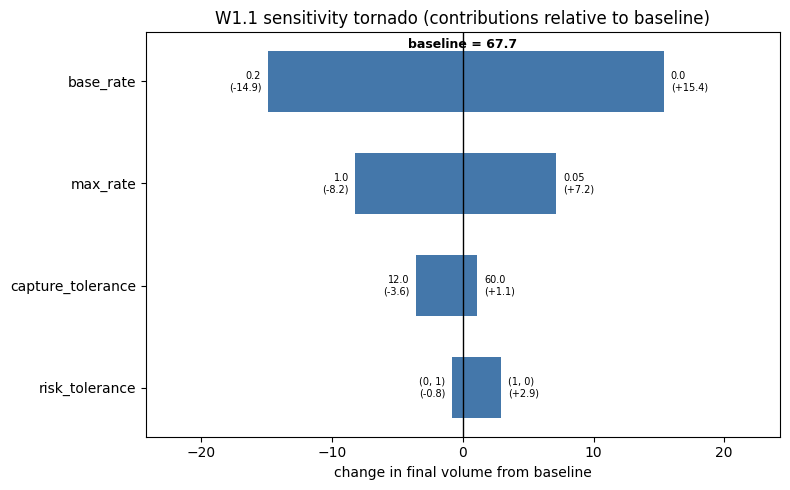

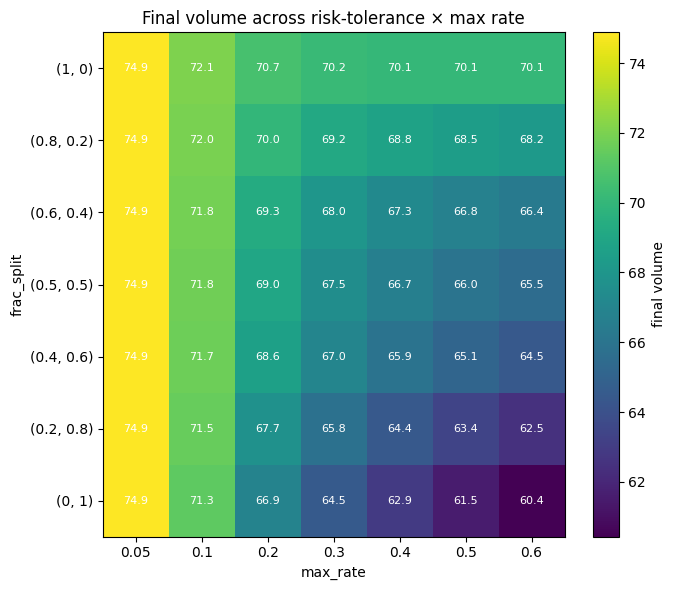

In [7]:
w11_plot_tornado()
w11_plot_heatmap()

World 1.2 Sensitivity Analysis Methods

In [8]:
def w12_plot_tornado():
    # PLOTTING THE TORNADO CHART FOR W1.2
    fig, ax = plt.subplots(figsize=(8,5))

    # getting sensitivity dataframes
    w12_base_df = sag.w12_sensitivity_sweep("base_rate", [0, 0.05, 0.2], 300)
    w12_max_df = sag.w12_sensitivity_sweep("max_rate", [0.05, 0.1, 0.2, 0.8, 0.9, 1.0], 300)
    w12_captol_df = sag.w12_sensitivity_sweep("cap_tolerance", [12, 24, 36, 48, 60], 300)
    w12_risk_df = sag.w12_sensitivity_sweep("frac_split", [(0, 1), (1, 0)], 300)
    w12_hammock_df = sag.w12_sensitivity_sweep("hammock_threshold", [0, 1], 300)

    # get the baseline reading
    w12_baseline_mc, _ = sag.w12_monte_carlo(300, **BASELINE12)
    w12_baseline_results = sag.w12_analyze_monte_carlo(w12_baseline_mc)
    w12_baseline_final_vol = w12_baseline_results["average final volume"]

    tornado = sag.w12_make_tornado(base_df=w12_base_df, 
                               max_df=w12_max_df, 
                               risk_df=w12_risk_df, 
                               captol_df=w12_captol_df, 
                               hammock_df=w12_hammock_df,
                               metric_col="final vol", 
                               baseline=w12_baseline_final_vol)

    for i, r in enumerate(tornado.itertuples()):
        left = min(r.low_delta, r.high_delta)
        width = abs(r.high_delta - r.low_delta)
        ax.barh(i, width, left=left, height=0.6, color="#4477aa")

        offset = 0.5   # how far outside the bar end to place the label
        # negative-side label goes further left (outside), right-aligned
        ax.text(min(r.low_delta, r.high_delta) - offset, i,
                f"{r.low_param}\n({r.low_delta:+.1f})",
                va="center", ha="right", fontsize=7)
        # positive-side label goes further right (outside), left-aligned
        ax.text(max(r.low_delta, r.high_delta) + offset, i,
            f"{r.high_param}\n({r.high_delta:+.1f})",
            va="center", ha="left", fontsize=7)

    span = max(tornado["high_delta"].max(), tornado["low_delta"].max()) - min(tornado["high_delta"].min(), tornado["low_delta"].min())
    ax.set_xlim(-span*0.9, span*0.9)   # generous room on both sides for labels

    ax.axvline(0, color="black", lw=1)   # baseline is now at 0
    ax.text(0, len(tornado) - 0.7, f"baseline = {w12_baseline_final_vol:.1f}",
        ha="center", va="bottom", fontsize=9, fontweight="bold")
    
    ax.set_yticks(range(len(tornado)))
    ax.set_yticklabels(tornado["param"])
    ax.set_xlabel("change in final volume from baseline")
    ax.set_title("W1.2 sensitivity tornado (contributions relative to baseline)")
    plt.tight_layout()
    plt.savefig("w12_final_vol_tornado.png", dpi=120)

# PLOTTING THE HEAT MAP FOR W1.2
def w12_plot_heatmap():
    df_2d = sag.w12_two_variable_sweep("frac_split", [(0, 1), (0.2, 0.8), (0.4, 0.6), (0.5, 0.5), (0.6, 0.4), (0.8, 0.2), (1, 0)], "hammock_threshold", [0, 0.2, 0.4, 0.5, 0.6, 0.8, 1], 300)
    grid = df_2d.pivot(index="frac_split", columns="hammock_threshold", values="final vol")

    fig, ax = plt.subplots(figsize=(7, 6))
    im = ax.imshow(grid, origin="lower", aspect="auto", cmap="viridis")
    ax.set_xticks(range(len(grid.columns)))
    ax.set_xticklabels(grid.columns)
    ax.set_yticks(range(len(grid.index)))
    ax.set_yticklabels(grid.index)
    ax.set_xlabel("hammok_threshold")
    ax.set_ylabel("frac_split")
    ax.set_title("Final volume across risk-tolerance × build-out threshold")
    fig.colorbar(im, ax=ax, label="final volume")

    # optional: annotate each cell with its value
    for i in range(len(grid.index)):
        for j in range(len(grid.columns)):
            ax.text(j, i, f"{grid.iloc[i,j]:.1f}", ha="center", va="center", color="white", fontsize=8)
    plt.tight_layout()
    plt.savefig("w12_split_ham_heatmap.png", dpi=120)

World 1.2 Sensitivity Analysis Results

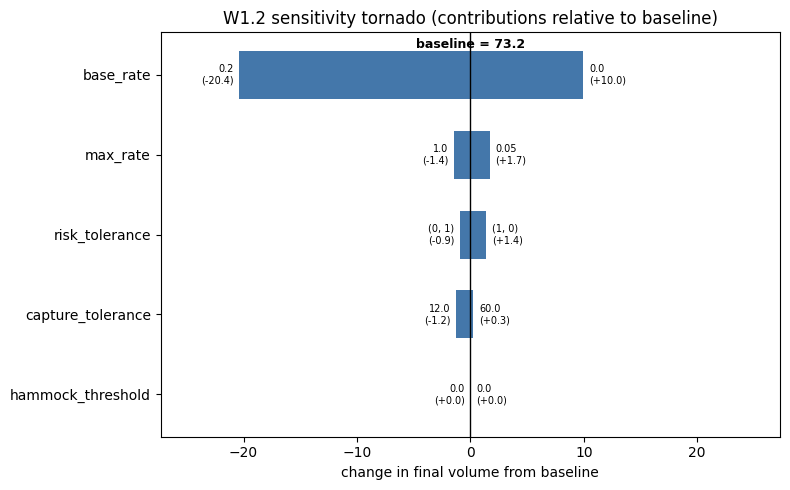

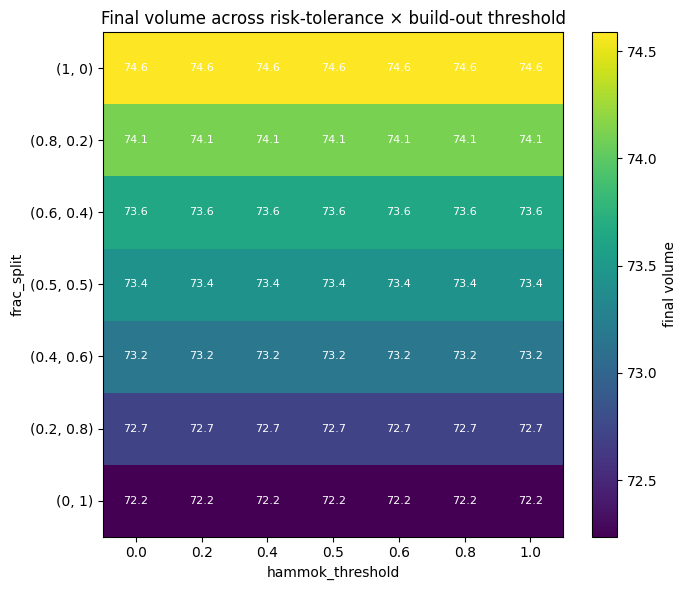

In [9]:
w12_plot_tornado()
w12_plot_heatmap()

World 2 Sensitivity Analysis Methods

In [10]:
def w2_plot_tornado():
    # PLOTTING THE TORNADO CHART FOR W2
    fig, ax = plt.subplots(figsize=(8,5))

    # getting sensitivity dataframes
    lp_df = sag.w2_sensitivity_sweep("late_penalty", [0.2, 0.6, 0.8, 1], 300)
    base_df = sag.w2_sensitivity_sweep("base_rate", [0, 0.05, 0.2], 300)
    thresh_df = sag.w2_sensitivity_sweep("threshold_frac", [0, 0.2, 0.3, 0.35, 0.4, 0.45, 0.5, 0.6, 0.7, 0.8, 0.9, 1], 300)
    max_df = sag.w2_sensitivity_sweep("max_rate", [0.05, 0.1, 0.2, 0.8, 0.9, 1.0], 300)
    # sample_df = sensitivity_sweep("sampling", False, 300)

    # get the baseline reading
    w2_baseline_mc, _ = sag.w2_monte_carlo(300, **BASELINE2)
    w2_baseline_results = sag.w2_analyze_monte_carlo(w2_baseline_mc)
    w2_baseline_final_vol = w2_baseline_results["average final vol of capture"]

    tornado = sag.w2_make_tornado(lp_df=lp_df, base_df=base_df, thresh_df=thresh_df, max_df=max_df, metric_col="final vol", baseline=w2_baseline_final_vol)

    for i, r in enumerate(tornado.itertuples()):
        left = min(r.low_delta, r.high_delta)
        width = abs(r.high_delta - r.low_delta)
        ax.barh(i, width,  left=left, height=0.6, color="#4477aa")  # low param value

        offset = 0.5   # how far outside the bar end to place the label
        # negative-side label goes further left (outside), right-aligned
        ax.text(min(r.low_delta, r.high_delta) - offset, i,
                f"{r.low_param}\n({r.low_delta:+.1f})",
                va="center", ha="right", fontsize=7)
        # positive-side label goes further right (outside), left-aligned
        ax.text(max(r.low_delta, r.high_delta) + offset, i,
            f"{r.high_param}\n({r.high_delta:+.1f})",
            va="center", ha="left", fontsize=7)

    span = max(tornado["high_delta"].max(), tornado["low_delta"].max()) - min(tornado["high_delta"].min(), tornado["low_delta"].min())
    ax.set_xlim(-span*0.7, span*0.7)   # generous room on both sides for labels

    ax.axvline(0, color="black", lw=1)   # baseline is now at 0
    ax.text(0, len(tornado) - 0.3, f"baseline = {w2_baseline_final_vol:.1f}",
        ha="center", va="bottom", fontsize=9, fontweight="bold")

    ax.set_yticks(range(len(tornado)))
    ax.set_yticklabels(tornado["param"])
    ax.set_xlabel("change in final volume from baseline")
    ax.set_title("W2 sensitivity tornado (contributions relative to baseline)")
    plt.tight_layout()
    plt.savefig("w2_final_vol_tornado.png", dpi=120)

def w2_plot_heatmap():
     # PLOTTING THE HEAT MAP FOR W2 
    # assume df_2d has columns: late_penalty, threshold_frac, final_vol
    df_2d = sag.w2_two_variable_sweep("threshold_frac", [0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8], "late_penalty", [0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8], 300)
    grid = df_2d.pivot(index="late_penalty", columns="threshold_frac", values="final vol")

    fig, ax = plt.subplots(figsize=(7, 6))
    im = ax.imshow(grid, origin="lower", aspect="auto", cmap="viridis")
    ax.set_xticks(range(len(grid.columns)))
    ax.set_xticklabels(grid.columns)
    ax.set_yticks(range(len(grid.index)))
    ax.set_yticklabels(grid.index)
    ax.set_xlabel("threshold_frac")
    ax.set_ylabel("late_penalty")
    ax.set_title("Final volume across late_penalty × threshold_frac")
    fig.colorbar(im, ax=ax, label="final volume")

    # optional: annotate each cell with its value
    for i in range(len(grid.index)):
        for j in range(len(grid.columns)):
            ax.text(j, i, f"{grid.iloc[i,j]:.1f}", ha="center", va="center", color="white", fontsize=8)
    plt.tight_layout()
    plt.savefig("w2_frac_pen_heatmap.png", dpi=120)

World 2 Sensitivity Analysis Results

KeyboardInterrupt: 

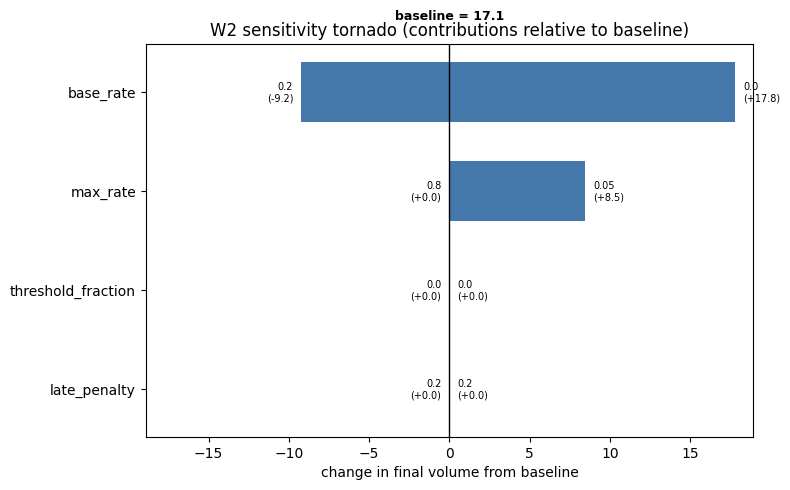

In [11]:
w2_plot_tornado()
w2_plot_heatmap()